# MNIST Digit Classification - Kata Tecnica Senior ML

Notebook oficial del reto:
- Entrenamiento de una CNN con Keras (sin modelos preentrenados)
- Evaluacion en conjunto de prueba
- Curvas de accuracy/loss
- Exportacion del modelo en `.h5` hacia `api/model/mnist_cnn.h5`

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import classification_report, confusion_matrix

# Reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow: {tf.__version__}")

TensorFlow: 2.16.2


In [6]:
# Carga y preprocesamiento
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = mnist.load_data()

X_train = (X_train_raw.astype("float32") / 255.0)[..., np.newaxis]
X_test = (X_test_raw.astype("float32") / 255.0)[..., np.newaxis]

y_train = to_categorical(y_train_raw, 10)
y_test = to_categorical(y_test_raw, 10)

val_size = int(0.1 * len(X_train))
X_val, y_val = X_train[:val_size], y_train[:val_size]
X_tr, y_tr = X_train[val_size:], y_train[val_size:]

print("Train:", X_tr.shape, y_tr.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (54000, 28, 28, 1) (54000, 10)
Val: (6000, 28, 28, 1) (6000, 10)
Test: (10000, 28, 28, 1) (10000, 10)


In [7]:
# Modelo CNN
model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, 3, activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.Conv2D(32, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(2),
    layers.Dropout(0.25),

    layers.Conv2D(64, 3, activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.Conv2D(64, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(2),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax"),
], name="mnist_cnn")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "mnist_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 871,018 (3.32 MB)

 Trainable params: 870,826 (3.32 MB)

 Non-trainable params: 192 (768.00 B)

### Data augmentation + inversion de colores

MNIST tiene fondo negro y digito blanco. Las fotos reales tienen fondo blanco y digito negro. Invertir el dataset duplica los ejemplos y ensena al modelo ambos casos. El augmentation adicional simula variaciones de angulo y posicion tipicas de fotos tomadas con celular.

In [8]:
# Data augmentation + entrenamiento
os.makedirs("api/model", exist_ok=True)

X_invertido = 1.0 - X_tr
y_invertido = y_tr.copy()

X_combinado = np.concatenate([X_tr, X_invertido], axis=0)
y_combinado = np.concatenate([y_tr, y_invertido], axis=0)

print("Train original:", X_tr.shape, y_tr.shape)
print("Train combinado:", X_combinado.shape, y_combinado.shape)

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
)

callbacks = [
    EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint(
        filepath="api/model/mnist_cnn_best.h5",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1,
    ),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1),
]

steps_per_epoch = max(1, len(X_combinado) // 128)

history = model.fit(
    datagen.flow(X_combinado, y_combinado, batch_size=128),
    validation_data=(X_val, y_val),
    epochs=20,
    steps_per_epoch=steps_per_epoch,
    callbacks=callbacks,
    verbose=1,
)

Train original: (54000, 28, 28, 1) (54000, 10)
Train combinado: (108000, 28, 28, 1) (108000, 10)
Epoch 1/20
842/843 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.4884 - loss: 1.5176
Epoch 1: val_accuracy improved from None to 0.97350, saving model to api/model/mnist_cnn_best.h5



Epoch 1: finished saving model to api/model/mnist_cnn_best.h5
843/843 ━━━━━━━━━━━━━━━━━━━━ 31s 36ms/step - accuracy: 0.6789 - loss: 0.9025 - val_accuracy: 0.9735 - val_loss: 0.0817 - learning_rate: 0.0010
Epoch 2/20
  1/843 ━━━━━━━━━━━━━━━━━━━━ 30s 37ms/step - accuracy: 0.8594 - loss: 0.4492
Epoch 2: val_accuracy did not improve from 0.97350
843/843 ━━━━━━━━━━━━━━━━━━━━ 1s 760us/step - accuracy: 0.8594 - loss: 0.4492 - val_accuracy: 0.9723 - val_loss: 0.0852 - learning_rate: 0.0010
Epoch 3/20
842/843 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8783 - loss: 0.3609
Epoch 3: val_accuracy improved from 0.97350 to 0.98483, saving model to api/model/mnist_cnn_best.h5



Epoch 3: finished saving model to api/model/mnist_cnn_best.h5
843/843 ━━━━━━━━━━━━━━━━━━━━ 31s 36ms/step - accuracy: 0.9021 - loss: 0.2979 - val_accuracy: 0.9848 - val_loss: 0.0565 - learning_rate: 0.0010
Epoch 4/20
  1/843 ━━━━━━━━━━━━━━━━━━━━ 28s 34ms/step - accuracy: 0.9219 - loss: 0.3537
Epoch 4: val_accuracy did not improve from 0.98483
843/843 ━━━━━━━━━━━━━━━━━━━━ 1s 717us/step - accuracy: 0.9219 - loss: 0.3537 - val_accuracy: 0.9845 - val_loss: 0.0559 - learning_rate: 0.0010
Epoch 5/20
842/843 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9483 - loss: 0.1696
Epoch 5: val_accuracy improved from 0.98483 to 0.98583, saving model to api/model/mnist_cnn_best.h5



Epoch 5: finished saving model to api/model/mnist_cnn_best.h5
843/843 ━━━━━━━━━━━━━━━━━━━━ 31s 37ms/step - accuracy: 0.9549 - loss: 0.1518 - val_accuracy: 0.9858 - val_loss: 0.0455 - learning_rate: 0.0010
Epoch 6/20
  1/843 ━━━━━━━━━━━━━━━━━━━━ 30s 37ms/step - accuracy: 0.9766 - loss: 0.1095
Epoch 6: val_accuracy did not improve from 0.98583
843/843 ━━━━━━━━━━━━━━━━━━━━ 1s 712us/step - accuracy: 0.9766 - loss: 0.1095 - val_accuracy: 0.9850 - val_loss: 0.0483 - learning_rate: 0.0010
Epoch 7/20
843/843 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9691 - loss: 0.1113
Epoch 7: val_accuracy improved from 0.98583 to 0.98967, saving model to api/model/mnist_cnn_best.h5



Epoch 7: finished saving model to api/model/mnist_cnn_best.h5
843/843 ━━━━━━━━━━━━━━━━━━━━ 30s 35ms/step - accuracy: 0.9713 - loss: 0.1036 - val_accuracy: 0.9897 - val_loss: 0.0402 - learning_rate: 0.0010
Epoch 8/20
  1/843 ━━━━━━━━━━━━━━━━━━━━ 27s 33ms/step - accuracy: 0.9922 - loss: 0.0437
Epoch 8: val_accuracy did not improve from 0.98967
843/843 ━━━━━━━━━━━━━━━━━━━━ 1s 692us/step - accuracy: 0.9922 - loss: 0.0437 - val_accuracy: 0.9890 - val_loss: 0.0395 - learning_rate: 0.0010
Epoch 9/20
843/843 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9751 - loss: 0.0852
Epoch 9: val_accuracy improved from 0.98967 to 0.99167, saving model to api/model/mnist_cnn_best.h5



Epoch 9: finished saving model to api/model/mnist_cnn_best.h5
843/843 ━━━━━━━━━━━━━━━━━━━━ 32s 37ms/step - accuracy: 0.9768 - loss: 0.0809 - val_accuracy: 0.9917 - val_loss: 0.0345 - learning_rate: 0.0010
Epoch 10/20
  1/843 ━━━━━━━━━━━━━━━━━━━━ 28s 34ms/step - accuracy: 0.9688 - loss: 0.0549
Epoch 10: val_accuracy did not improve from 0.99167
843/843 ━━━━━━━━━━━━━━━━━━━━ 1s 711us/step - accuracy: 0.9688 - loss: 0.0549 - val_accuracy: 0.9917 - val_loss: 0.0342 - learning_rate: 0.0010
Epoch 11/20
842/843 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9787 - loss: 0.0737
Epoch 11: val_accuracy did not improve from 0.99167
843/843 ━━━━━━━━━━━━━━━━━━━━ 31s 37ms/step - accuracy: 0.9797 - loss: 0.0705 - val_accuracy: 0.9905 - val_loss: 0.0331 - learning_rate: 0.0010
Epoch 12/20
  1/843 ━━━━━━━━━━━━━━━━━━━━ 29s 35ms/step - accuracy: 0.9922 - loss: 0.0439
Epoch 12: val_accuracy did not improve from 0.99167
843/843 ━━━━━━━━━━━━━━━━━━━━ 1s 711us/step - accuracy: 0.9922 - loss: 0.0439 - val_acc


Epoch 13: finished saving model to api/model/mnist_cnn_best.h5
843/843 ━━━━━━━━━━━━━━━━━━━━ 31s 37ms/step - accuracy: 0.9824 - loss: 0.0637 - val_accuracy: 0.9938 - val_loss: 0.0251 - learning_rate: 0.0010
Epoch 14/20
  1/843 ━━━━━━━━━━━━━━━━━━━━ 29s 35ms/step - accuracy: 0.9766 - loss: 0.0423
Epoch 14: val_accuracy did not improve from 0.99383
843/843 ━━━━━━━━━━━━━━━━━━━━ 1s 696us/step - accuracy: 0.9766 - loss: 0.0423 - val_accuracy: 0.9935 - val_loss: 0.0253 - learning_rate: 0.0010
Epoch 15/20
842/843 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9835 - loss: 0.0568
Epoch 15: val_accuracy did not improve from 0.99383
843/843 ━━━━━━━━━━━━━━━━━━━━ 30s 36ms/step - accuracy: 0.9840 - loss: 0.0556 - val_accuracy: 0.9922 - val_loss: 0.0278 - learning_rate: 0.0010
Epoch 16/20
  1/843 ━━━━━━━━━━━━━━━━━━━━ 29s 35ms/step - accuracy: 1.0000 - loss: 0.0181
Epoch 16: val_accuracy did not improve from 0.99383

Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
843/843


Epoch 17: finished saving model to api/model/mnist_cnn_best.h5
843/843 ━━━━━━━━━━━━━━━━━━━━ 31s 37ms/step - accuracy: 0.9875 - loss: 0.0432 - val_accuracy: 0.9948 - val_loss: 0.0210 - learning_rate: 5.0000e-04
Epoch 18/20
  1/843 ━━━━━━━━━━━━━━━━━━━━ 30s 36ms/step - accuracy: 0.9844 - loss: 0.0359
Epoch 18: val_accuracy improved from 0.99483 to 0.99517, saving model to api/model/mnist_cnn_best.h5



Epoch 18: finished saving model to api/model/mnist_cnn_best.h5
843/843 ━━━━━━━━━━━━━━━━━━━━ 1s 712us/step - accuracy: 0.9844 - loss: 0.0359 - val_accuracy: 0.9952 - val_loss: 0.0206 - learning_rate: 5.0000e-04
Epoch 19/20
843/843 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9897 - loss: 0.0373
Epoch 19: val_accuracy did not improve from 0.99517
843/843 ━━━━━━━━━━━━━━━━━━━━ 31s 36ms/step - accuracy: 0.9893 - loss: 0.0379 - val_accuracy: 0.9930 - val_loss: 0.0238 - learning_rate: 5.0000e-04
Epoch 20/20
  1/843 ━━━━━━━━━━━━━━━━━━━━ 29s 35ms/step - accuracy: 0.9922 - loss: 0.1139
Epoch 20: val_accuracy did not improve from 0.99517
843/843 ━━━━━━━━━━━━━━━━━━━━ 1s 726us/step - accuracy: 0.9922 - loss: 0.1139 - val_accuracy: 0.9932 - val_loss: 0.0239 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 18.


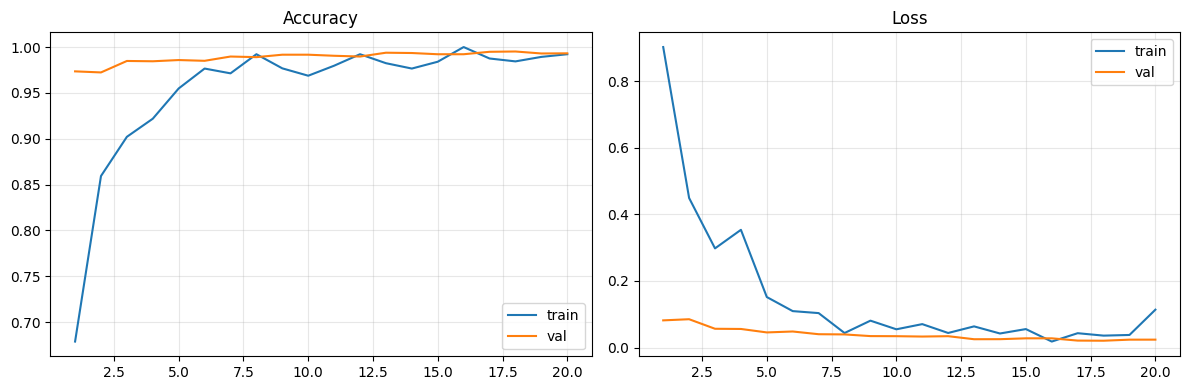

In [9]:
# Curvas de entrenamiento (accuracy / loss)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, len(history.history["accuracy"]) + 1)
axes[0].plot(epochs, history.history["accuracy"], label="train")
axes[0].plot(epochs, history.history["val_accuracy"], label="val")
axes[0].set_title("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history.history["loss"], label="train")
axes[1].plot(epochs, history.history["val_loss"], label="val")
axes[1].set_title("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("api/model/training_curves.png", dpi=140, bbox_inches="tight")
plt.show()

Test loss: 0.0145
Test accuracy: 0.9956

Classification report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       1.00      0.99      0.99      1135
           2       0.99      1.00      1.00      1032
           3       1.00      1.00      1.00      1010
           4       0.99      1.00      1.00       982
           5       1.00      0.99      1.00       892
           6       1.00      0.99      0.99       958
           7       1.00      1.00      1.00      1028
           8       0.99      1.00      1.00       974
           9       1.00      1.00      1.00      1009

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



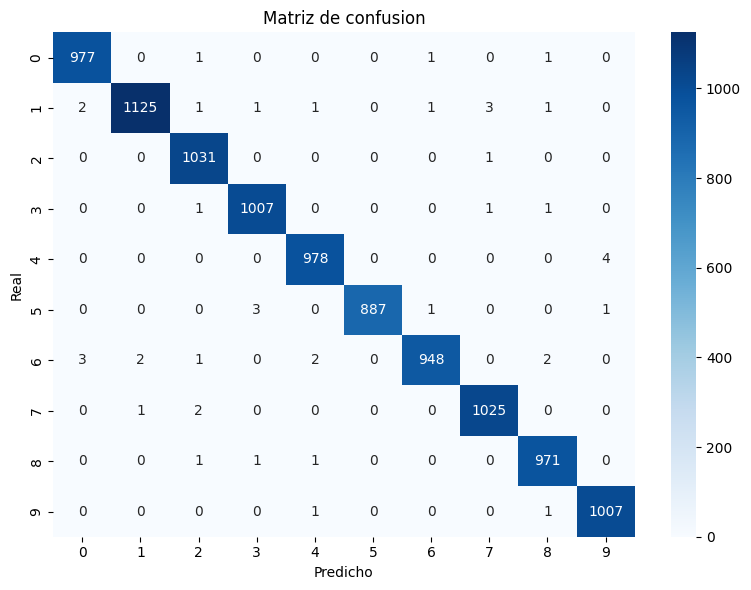

In [10]:
# Evaluacion
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

y_pred_proba = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print("\nClassification report:")
print(classification_report(y_test_raw, y_pred, target_names=[str(i) for i in range(10)]))

cm = confusion_matrix(y_test_raw, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusion")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.tight_layout()
plt.savefig("api/model/confusion_matrix.png", dpi=140, bbox_inches="tight")
plt.show()

### Validacion visual de 32 imagenes

Validacion visual obligatoria sobre el set de prueba - datos que el modelo nunca vio durante entrenamiento. Verde = correcto, Rojo = incorrecto.

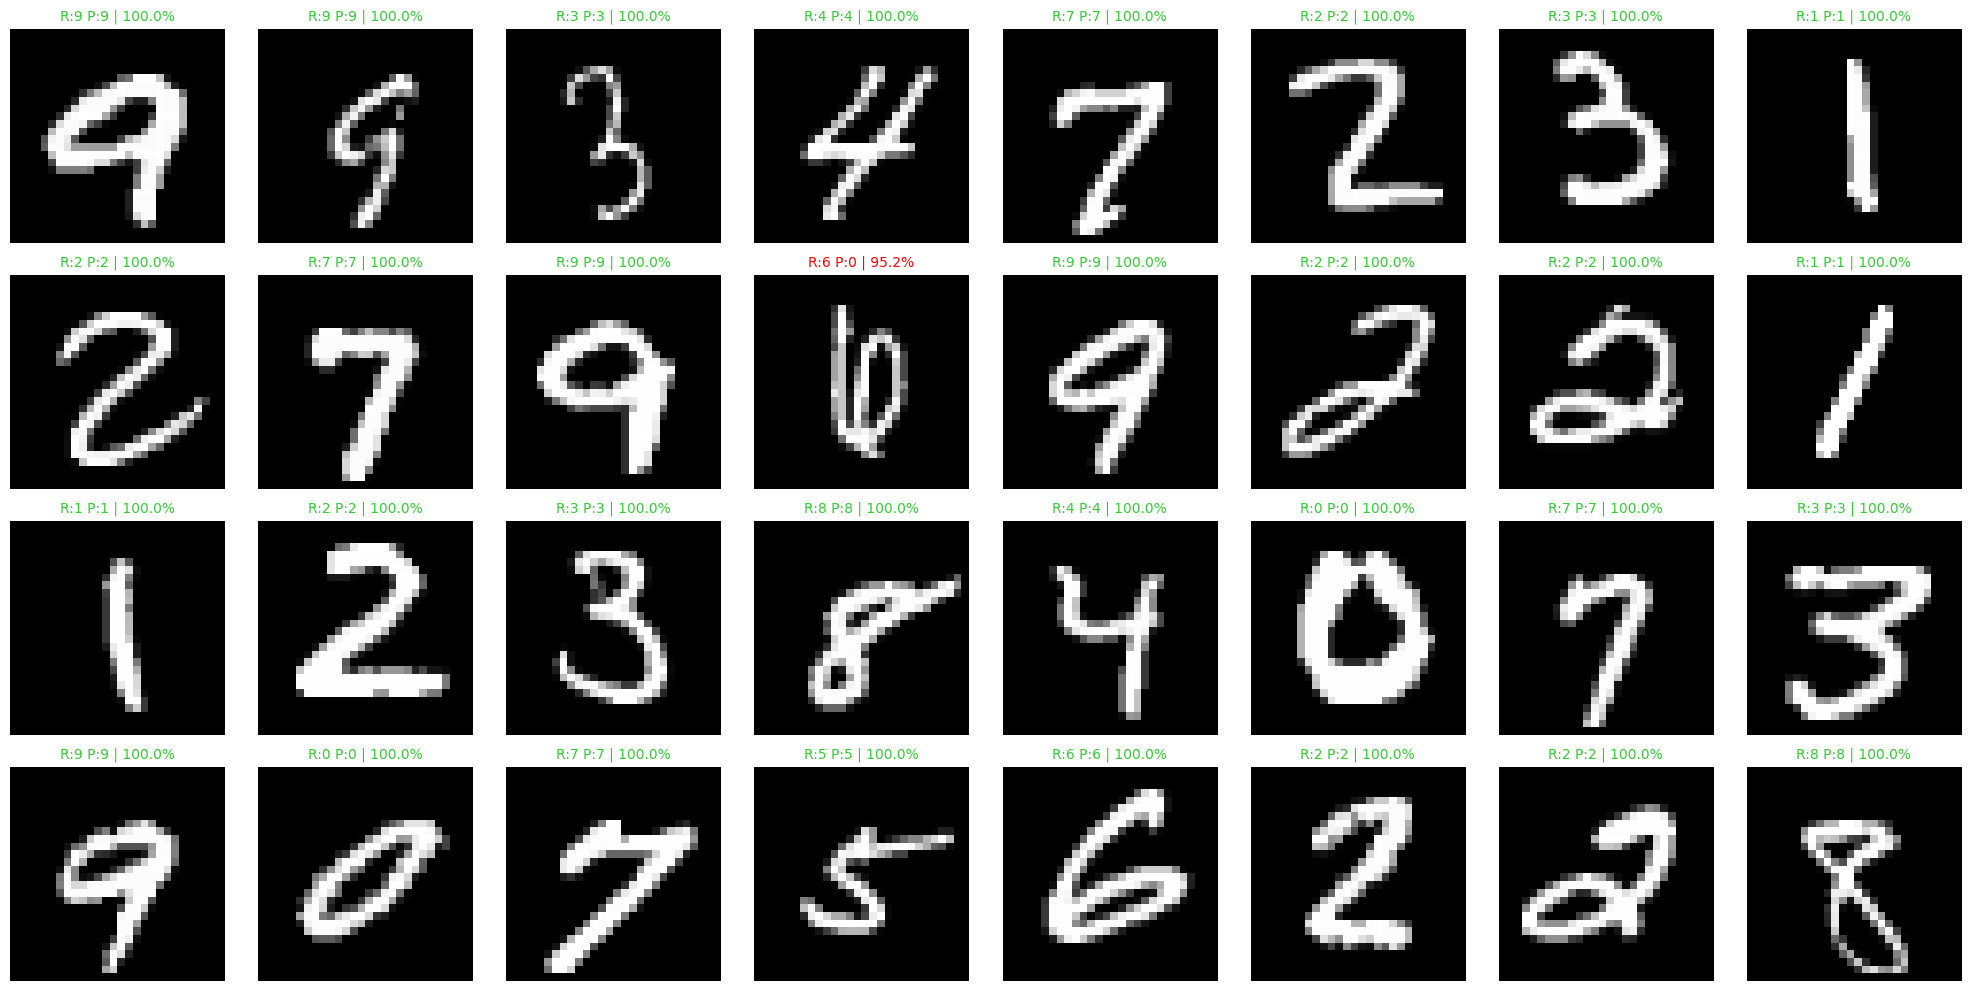

In [11]:
# Validacion visual (32 imagenes del set de prueba)
num_samples = 32
indices = np.random.choice(len(X_test), size=num_samples, replace=False)

x_batch = X_test[indices]
y_true_batch = y_test_raw[indices]

proba_batch = model.predict(x_batch, verbose=0)
y_pred_batch = np.argmax(proba_batch, axis=1)
conf_batch = np.max(proba_batch, axis=1)

fig, axes = plt.subplots(4, 8, figsize=(20, 10))
axes = axes.flatten()

for i, ax in enumerate(axes):
    img = np.squeeze(x_batch[i], axis=-1)
    real = int(y_true_batch[i])
    pred = int(y_pred_batch[i])
    conf = float(conf_batch[i] * 100)
    ok = real == pred

    ax.imshow(img, cmap="gray")
    ax.set_title(
        f"R:{real} P:{pred} | {conf:.1f}%",
        color=("limegreen" if ok else "red"),
        fontsize=10,
    )
    ax.axis("off")

plt.tight_layout()
plt.savefig("api/model/validacion_32_imagenes.png", dpi=140, bbox_inches="tight")
plt.show()

In [12]:
# Exportacion final (.h5) alineada con la API
MODEL_PATH = "api/model/mnist_cnn.h5"
model.save(MODEL_PATH)

print("Modelo exportado en:", MODEL_PATH)
print("Existe?:", os.path.exists(MODEL_PATH))
print("Tamano (KB):", round(os.path.getsize(MODEL_PATH) / 1024, 1))

loaded = keras.models.load_model(MODEL_PATH)
loaded_acc = loaded.evaluate(X_test, y_test, verbose=0)[1]
print("Accuracy modelo cargado:", round(float(loaded_acc), 4))

Modelo exportado en: api/model/mnist_cnn.h5
Existe?: True
Tamano (KB): 10278.2
Accuracy modelo cargado: 0.9956
